In [16]:
from datetime import date

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

In [21]:
file_path = "Files/nist_1b_202501_filtered_03.h5"

def cargar_banda(file_path, band_path, include_lunar=False):
    with h5py.File(file_path, "r") as f:
        dset = f[band_path]

        time = np.array(dset["DSCOVREpochTime"][:], dtype=np.float64)

        radiance = dset["EarthRadiance"][:]
        radiance = radiance.byteswap().view(radiance.dtype.newbyteorder("="))

        interp = np.array(dset["isInterpolated"][:])

        data = {
            "Time": time,
            "Radiance": radiance,
            "Is_interpolated": interp
        }

        if include_lunar:
            lunar = dset["LunarCorrection"][:]
            data["LunarCorrection"] = lunar

        return pd.DataFrame(data)

<Axes: xlabel='Time'>

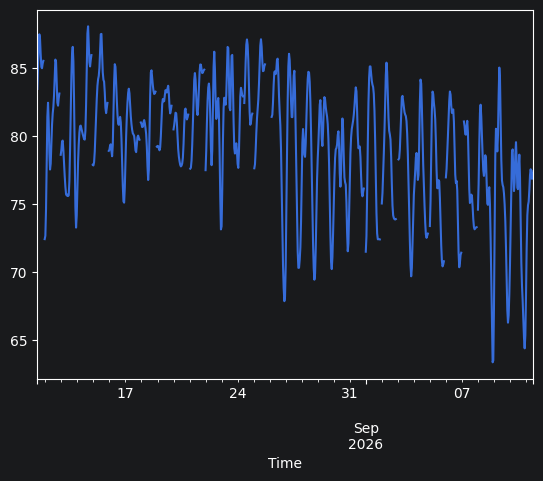

In [31]:
df_bandA = cargar_banda(file_path, "Earth_Radiance_Filtered/Band A (Total)")
df_bandB = cargar_banda(file_path, "Earth_Radiance_Filtered/Band B (Shortwave)", include_lunar=True)
df_bandC = cargar_banda(file_path, "Earth_Radiance_Filtered/Band C (NIR)")

df_bandB["Time"] = pd.to_datetime(df_bandB["Time"], unit="s")
df_bandB.set_index("Time")["Radiance"].resample("1h").mean().plot()

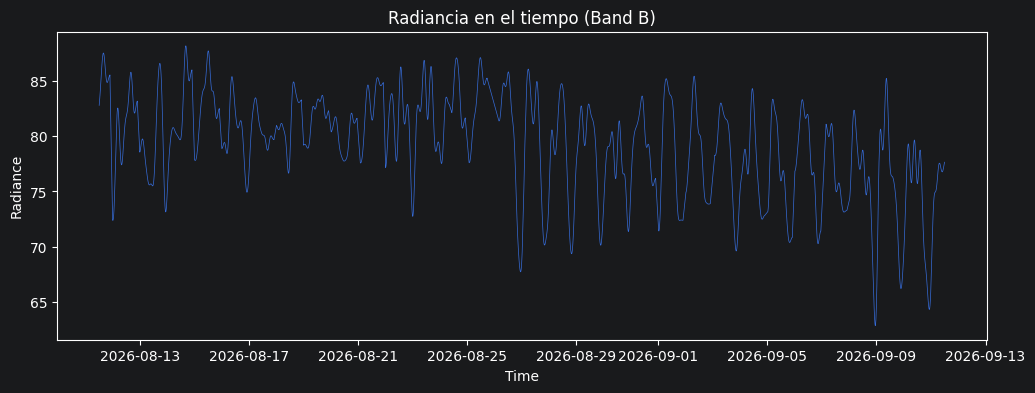

In [29]:
plt.figure(figsize=(12,4))
plt.plot(df_bandB["Time"], df_bandB["Radiance"], linewidth=0.5)
plt.title("Radiancia en el tiempo (Band B)")
plt.xlabel("Time")
plt.ylabel("Radiance")
plt.show()